In [21]:
import json
import numpy as np
import pandas as pd
from os.path import join
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [22]:
def assign_ate_groups(intervention: str, variable: str) -> tuple[str, str, str]:
    """
    Assign distribution, structure, and path_type groups to an (intervention, variable) pair.
    
    Args:
        intervention: String like "S1=0.5", "S3=1.0", etc.
        variable: String like "X1", "X2", etc.
    
    Returns:
        tuple: (distribution_group, structure_group, path_type)
            - distribution_group: "ID" (in-distribution) or "OOD" (out-of-distribution)
            - structure_group: "zero" (no causal path) or "nonzero" (has causal path)
            - path_type: "zero" | "direct" | "indirect"
              direct  = S is a DIRECT parent of X (cross-attention mask allows it)
              indirect = S is an ancestor but NOT a direct parent (mask blocks the shortcut)
              zero    = no causal path from S to X
    """
    # Parse intervention
    src_var, value_str = intervention.split("=")
    value = float(value_str)
    
    # Distribution classification (ID vs OOD)
    # Unified scheme: OOD value = 1.5 for all sources (outside continuous support [-1,1])
    ood_interventions = {
        "S2": [1.5],
        "S3": [1.5],
        "S5": [1.5],
    }
    is_ood = src_var in ood_interventions and value in ood_interventions[src_var]
    dist_group = "OOD" if is_ood else "ID"
    
    # All descendants (transitive closure) for structure_group
    descendants = {
        "S1": [],                       # Dangling, no effect on any X
        "S2": ["X1", "X5"],             # S2 → X1 → X5
        "S3": ["X2", "X3", "X4", "X5"], # S3 → X2,X3; X2 → X4,X5
        "S4": ["X4"],                   # S4 → X4
        "S5": ["X4"],                   # S5 → X4
    }
    
    # Direct children only (edges in cross-attention mask)
    direct_children = {
        "S1": [],               # Dangling
        "S2": ["X1"],           # S2 → X1 (direct)
        "S3": ["X2", "X3"],     # S3 → X2, X3 (direct)
        "S4": ["X4"],           # S4 → X4 (direct)
        "S5": ["X4"],           # S5 → X4 (direct)
    }
    
    has_effect = variable in descendants.get(src_var, [])
    struct_group = "nonzero" if has_effect else "zero"
    
    # Path type classification
    if not has_effect:
        path_type = "zero"
    elif variable in direct_children.get(src_var, []):
        path_type = "direct"
    else:
        path_type = "indirect"  # ancestor but not direct parent
    
    return dist_group, struct_group, path_type


def add_ate_groups(df: pd.DataFrame) -> pd.DataFrame:
    """Add distribution, structure, and path_type group columns to dataframe."""
    df = df.copy()
    groups = df.apply(lambda row: assign_ate_groups(row["intervention"], row["variable"]), axis=1)
    df["dist_group"] = [g[0] for g in groups]
    df["struct_group"] = [g[1] for g in groups]
    df["path_type"] = [g[2] for g in groups]
    return df

# Usage:
# df = add_ate_groups(df)
# summary = df.groupby(["dist_group", "struct_group", "hard"])["abs_error_mean"].agg(["mean", "std", "count"])
# print(summary.to_latex())



def aggregate_ate_by_groups(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate ATE errors by (model, dataset, hard) for each of the 4 structure/distribution groups.
    
    Uses uncertainty propagation: when averaging N values with uncertainties σ_i,
    the combined uncertainty is sqrt(Σ σ_i² / N²) for independent measurements.
    
    Args:
        df: DataFrame with columns: model, dataset, hard, dist_group, struct_group,
            abs_error_mean, abs_error_std, rel_error_mean, rel_error_std
    
    Returns:
        DataFrame with aggregated metrics per (model, dataset, hard) and structure/distribution group
    """
    results = []
    
    # Group by experiment configuration
    for (model, dataset, hard), exp_df in df.groupby(["model", "dataset", "hard"]):
        
        # For each of the 4 groups
        for dist in ["ID", "OOD"]:
            for struct in ["zero", "nonzero"]:
                mask = (exp_df["dist_group"] == dist) & (exp_df["struct_group"] == struct)
                group_df = exp_df[mask]
                
                if len(group_df) == 0:
                    continue
                
                n = len(group_df)
                
                if "abs_error_std" in group_df.columns:
                    # Absolute error aggregation with uncertainty propagation
                    abs_means = group_df["abs_error_mean"].values
                    abs_stds = group_df["abs_error_std"].fillna(0).values

                    agg_abs_mean = np.mean(abs_means)
                    # Combined std: sqrt(sum of variances) / N for averaging
                    agg_abs_std = np.sqrt(np.sum(abs_stds**2)) / n

                    # Relative error aggregation (drop NaN for zero ATE cases)
                    scaled_df = group_df.dropna(subset=["scaled_error_mean"])
                    if len(scaled_df) > 0:
                        n_rel = len(scaled_df)
                        scaled_means = scaled_df["scaled_error_mean"].values
                        scaled_stds = scaled_df["scaled_error_std"].fillna(0).values

                        agg_scaled_mean = np.mean(scaled_means)
                        agg_scaled_std = np.sqrt(np.sum(scaled_stds**2)) / n_rel
                    else:
                        agg_scaled_mean = np.nan
                        agg_scaled_std = np.nan

                    results.append({
                        "model": model,
                        "dataset": dataset,
                        "hard": hard,
                        "dist_group": dist,
                        "struct_group": struct,
                        "group_label": f"{dist}_{struct}",
                        "n_pairs": n,
                        "abs_error": agg_abs_mean,
                        "abs_error_std": agg_abs_std,
                        "scaled_error": agg_scaled_mean,
                        "scaled_error_std": agg_scaled_std,
                    })
                else:
                    abs_means = group_df["abs_error"].values
                    agg_abs_mean = np.mean(abs_means)
                    results.append({
                        "model": model,
                        "dataset": dataset,
                        "hard": hard,
                        "dist_group": dist,
                        "struct_group": struct,
                        "group_label": f"{dist}_{struct}",
                        "n_pairs": 0,
                        "abs_error": agg_abs_mean,
                        "abs_error_std": None,
                        "scaled_error": None,
                        "scaled_error_std": None,
                    })
    
    return pd.DataFrame(results)


def format_latex_table(agg_df: pd.DataFrame) -> str:
    """
    Format aggregated results as LaTeX table.
    
    Rows: (model, dataset, hard)
    Columns: 4 groups × 2 metrics = 8 columns
    """
    # Pivot to wide format
    pivot_df = agg_df.pivot_table(
        index=["model", "dataset", "hard"],
        columns="group_label",
        values=["abs_error", "abs_error_std", "rel_error", "rel_error_std"],
        aggfunc="first"
    )
    
    # Format as mean ± std
    def fmt(mean, std):
        if pd.isna(mean):
            return "-"
        if pd.isna(std) or std == 0:
            return f"{mean:.3f}"
        return f"{mean:.3f} ± {std:.3f}"
    
    return pivot_df


# Usage:
# df = add_ate_groups(df)  # First add groups
# agg_df = aggregate_ate_by_groups(df)
# 
# # Display as pivot table
# display(agg_df.pivot_table(
#     index=["model", "dataset", "hard"],
#     columns="group_label",
#     values=["abs_error", "rel_error"]
# ))
#
# # Or export to LaTeX
# print(agg_df.to_latex(index=False, float_format="%.3f"))


In [23]:
ate_summary_filename = "ate_summary.csv"
experiment_summary_filename = "experiment_summary.csv"
intermediate_path = "eval/eval_seed_sweep/files"

baseline_list = [
    ## BASELINE
    {
        "model"     : "baseline",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/baseline_2layers_d48/euler/vanilla_transformer_scm1c_64574825"
        },
    {
        "model"     : "baseline",
        "dataset"   : "scm2",
        "hard"      : False,
        "filepath"  : "../experiments/baseline_2layers_d48/euler/vanilla_transformer_scm2c_64574804"
        },
    {
        "model"     : "baseline",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/baseline_2layers_d48/euler/vanilla_transformer_scm3c_64574723"
        },
]

df = None
dfe = None

for d in baseline_list:    
    # ATE df
    df_ = pd.read_csv(join(d["filepath"], intermediate_path, ate_summary_filename))
    df_["model"] = d["model"]
    df_["dataset"] = d["dataset"]
    df_["hard"] = d["hard"]
    
    if df is None:
        df = df_
    else:
        df = pd.concat([df, df_], axis=0)
    
    # exp df
    dfe_ = pd.read_csv(join(d["filepath"], intermediate_path, experiment_summary_filename))
    dfe_["model"] = d["model"]
    dfe_["dataset"] = d["dataset"]
    dfe_["hard"] = d["hard"]
    
    if dfe is None:
        dfe = dfe_
    else:
        dfe = pd.concat([dfe, dfe_], axis=0)
        
            
df = add_ate_groups(df)
df["intervention_on_variable"]=df["intervention"]+"_"+df["variable"]

df_ = df.set_index(["model", "hard", "dataset", "intervention", "variable", "dist_group", "struct_group", "path_type"])

agg_df = aggregate_ate_by_groups(df)

display(agg_df.pivot_table(
    index=["model", "dataset", "hard"],
    columns="group_label",
    values=["abs_error", "abs_error_std"]
))

abs_error                                  \
group_label            ID_nonzero   ID_zero OOD_nonzero  OOD_zero   
model    dataset hard                                               
baseline scm1    False   0.465767  0.063171    1.413046  0.197150   
         scm2    False   0.522952  0.057041    1.430483  0.178289   
         scm3    False   0.523204  0.059442    1.423154  0.184392   

                       abs_error_std                                  
group_label               ID_nonzero   ID_zero OOD_nonzero  OOD_zero  
model    dataset hard                                                 
baseline scm1    False      0.025859  0.010310    0.079249  0.040761  
         scm2    False      0.021856  0.009205    0.067916  0.036545  
         scm3    False      0.024076  0.010095    0.074273  0.039226

In [24]:
df

,intervention,variable,true_ate,model_ate_mean,model_ate_std,abs_error_mean,abs_error_std,scaled_error_mean,scaled_error_std,n_seeds,model,dataset,hard,dist_group,struct_group,path_type,intervention_on_variable
0,S1=0.5,X1,0.000000,-0.032317,0.069051,0.063715,0.037653,0.127431,0.075307,10,baseline,scm1,False,ID,zero,zero,S1=0.5_X1
1,S1=0.5,X2,0.000000,-0.032418,0.068967,0.063637,0.037743,0.127275,0.075485,10,baseline,scm1,False,ID,zero,zero,S1=0.5_X2
2,S1=0.5,X3,0.000000,-0.032635,0.069159,0.064053,0.037519,0.128106,0.075038,10,baseline,scm1,False,ID,zero,zero,S1=0.5_X3
3,S1=0.5,X4,0.000000,-0.032443,0.069303,0.064002,0.037697,0.128004,0.075394,10,baseline,scm1,False,ID,zero,zero,S1=0.5_X4
4,S1=0.5,X5,0.000000,-0.032324,0.069096,0.063670,0.037828,0.127339,0.075655,10,baseline,scm1,False,ID,zero,zero,S1=0.5_X5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,S5=1.5,X1,0.000000,-0.080554,0.207808,0.184457,0.110485,0.122971,0.073657,9,baseline,scm3,False,OOD,zero,zero,S5=1.5_X1
31,S5=1.5,X2,0.000000,-0.080269,0.208629,0.185157,0.110480,0.123438,0.073653,9,baseline,scm3,False,OOD,zero,zero,S5=1.5_X2
32,S5=1.5,X3,0.000000,-0.082041,0.207803,0.185290,0.110138,0.123526,0.073425,9,baseline,scm3,False,OOD,zero,zero,S5=1.5_X3
33,S5=1.5,X4,-0.006083,-0.081287,0.209105,0.183471,0.110537,0.122314,0.073691,9,baseline,scm3,False,OOD,nonzero,direct,S5=1.5_X4


In [25]:
dfe


,test_mae_mean,test_mae_std,val_mae_mean,val_mae_std,val_loss_mean,val_loss_std,best_train_loss_mean,best_train_loss_std,best_val_loss_mean,best_val_loss_std,...,gap_ratio_mean,gap_ratio_std,shd_cross_mean,shd_cross_std,mec_distance_mean,mec_distance_std,n_seeds,model,dataset,hard
0,0.019632,0.000215,0.019613,0.000165,0.000633,0.000010,0.000628,0.000006,0.000619,0.000003,...,-0.014136,0.011354,0.220091,0.056495,0.649350,0.064713,10,baseline,scm1,False
0,0.023732,0.000180,0.023689,0.000130,0.001015,0.000011,0.001005,0.000013,0.000997,0.000011,...,-0.007648,0.010217,0.218946,0.052620,0.635351,0.118496,10,baseline,scm2,False
0,0.018013,0.000543,0.018028,0.000526,0.000677,0.000031,0.000659,0.000010,0.000649,0.000007,...,-0.015410,0.018583,0.226985,0.053205,0.600087,0.110240,10,baseline,scm3,False


### N.B. Do not compare errors between different datasets, since they have different normalizations. Compare errors within the datasets, between models.

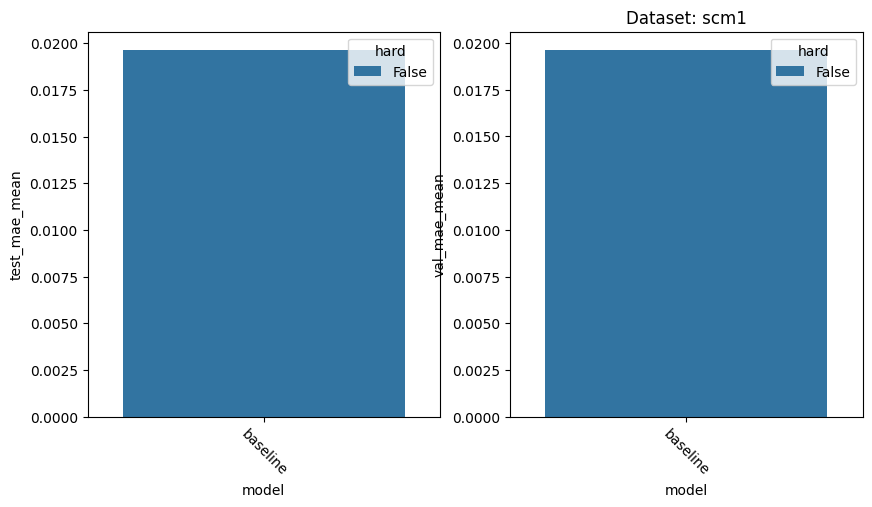

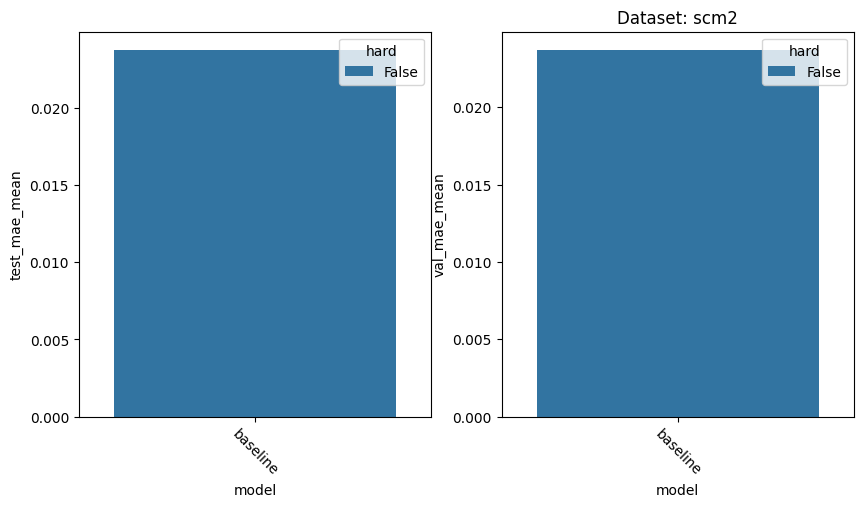

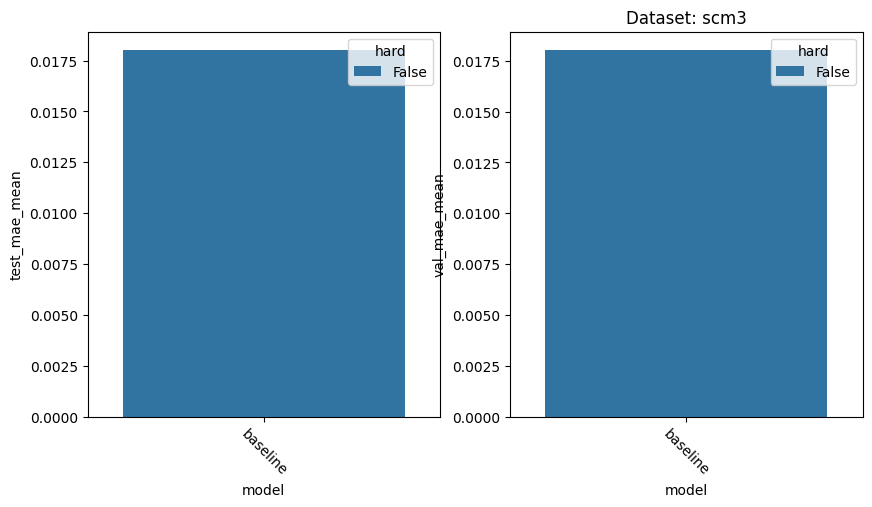

In [26]:
def plot_dataset_errors(dataset:str):
    _, axs = plt.subplots(1,2, figsize = (10,5))
    sns.barplot(dfe[dfe["dataset"]==dataset], x="model",y="test_mae_mean", hue="hard", ax=axs[0])
    sns.barplot(dfe[dfe["dataset"]==dataset].dropna(), x="model",y="val_mae_mean", hue="hard", ax=axs[1])
    for i in range(len(axs)):
        axs[i].tick_params(axis='x', labelrotation=-45)
    plt.title(f"Dataset: {dataset}")
    plt.show()

plot_dataset_errors("scm1")
plot_dataset_errors("scm2")
plot_dataset_errors("scm3")

Increasing the dimension helps the baseline but not Toeplitz_CC!

# Effects of Masking

#### Applying the mask reduces representation power and we loose the advantage of having the DAG in the first place in computing the ATE.

If the model cannot reconstruct the target with the true DAG provided to the attention, it will never be able to learn the true causal structure, in the context of causal discovery. We need enough model capacity such that applying the mask is not a treat for fitting the data.

In [27]:
# dfb = df_.loc["baseline"]
# dfb_diff = dfb.loc[False]["abs_error_mean"] - dfb.loc[True]["abs_error_mean"] # positive = mask better!
# dfb_diff.sort_values()
# sns.scatterplot(dfb_diff.reset_index(),x="variable",y="abs_error_mean",hue="path_type", style="dataset")
# plt.title("baseline")

Applying the true DAG mask 
1) Improves ATE involving non-ancestors and OOD values on ancestors 
2) Worsen ATE on some ID ancestors

Reason: probably worse fit with the mask. How to check?

---

# Benchmark

## Calitrain

In [28]:
experiment_metric_path = "k_0/logs/csv/version_0/metrics.csv"
ate_metrics_path = "eval/eval_ate_mc/files/ate_metrics_mc.csv"
causal_init_summary_path = "causal_init/causal_init_summary.json"


models_list = [
    # iter 1
    {
        "model"     : "single_sva_Toeplitz_CC_iter_1",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_1/euler/calitrain_single_Toeplitz_CC_svfa_scm1c_64464872"
        },
    {
        "model"     : "single_sva_Toeplitz_CC_iter_1",
        "dataset"   : "scm2",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_1/euler/calitrain_single_Toeplitz_CC_svfa_scm2c_64464918"
        },
    {
        "model"     : "single_sva_Toeplitz_CC_iter_1",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_1/euler/calitrain_single_Toeplitz_CC_svfa_scm3c_64465081"
        },
    
    # iter 2
    {
        "model"     : "single_sva_Toeplitz_CC_iter_2",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_2/euler/calitrain_single_Toeplitz_CC_svfa_scm1c_64638007"
        },
    {
        "model"     : "single_sva_Toeplitz_CC_iter_2",
        "dataset"   : "scm2",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_2/euler/calitrain_single_Toeplitz_CC_svfa_scm2c_64638059"
        },
    {
        "model"     : "single_sva_Toeplitz_CC_iter_2",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_2/euler/calitrain_single_Toeplitz_CC_svfa_scm3c_64638068"
        },
    
    # iter 3
    {
        "model"     : "single_sva_Toeplitz_CC_iter_3",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_3/euler/calitrain_single_Toeplitz_CC_svfa_scm1c_64697401"
        },
    {
        "model"     : "single_sva_Toeplitz_CC_iter_3",
        "dataset"   : "scm2",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_3/euler/calitrain_single_Toeplitz_CC_svfa_scm2c_64697409"
        },
    {
        "model"     : "single_sva_Toeplitz_CC_iter_3",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_3/euler/calitrain_single_Toeplitz_CC_svfa_scm3c_64697423"
        },
]


dfm = None
dfme = None
ci_rows = []  # causal init per-seed rows

for d in models_list:    
    # ATE df
    df_ = pd.read_csv(join(d["filepath"], ate_metrics_path))
    df_["model"] = d["model"]
    df_["dataset"] = d["dataset"]
    df_["hard"] = d["hard"]
    
    if dfm is None:
        dfm = df_
    else:
        dfm = pd.concat([dfm, df_], axis=0)
    
    # exp df
    dfme_ = pd.read_csv(join(d["filepath"], experiment_metric_path))

    dfme_["model"] = d["model"]
    dfme_["dataset"] = d["dataset"]
    dfme_["hard"] = d["hard"]
    
    if dfme is None:
        dfme = dfme_
    else:
        dfme = pd.concat([dfme, dfme_], axis=0)
    
    # causal init summary (per-seed HSIC & SHD)
    ci_file = join(d["filepath"], causal_init_summary_path)
    try:
        with open(ci_file) as f:
            ci_summary = json.load(f)
        for sr in ci_summary["seed_results"]:
            post = sr.get("post_init_metrics") or {}
            ci_rows.append({
                "model": d["model"],
                "dataset": d["dataset"],
                "seed": sr["seed"],
                "hsic_cross": sr["final_hsic_cross"],
                "hsic_self": sr.get("final_hsic_self"),
                "recon": sr["final_recon"],
                "shd_cross": post.get("soft_hamming_cross"),
                "shd_self": post.get("soft_hamming_self"),
                "decisiveness_cross": post.get("phi_cross_decisiveness"),
                "decisiveness_self": post.get("phi_self_decisiveness"),
            })
    except FileNotFoundError:
        print(f"  ⚠ causal_init_summary.json not found for {d['model']} / {d['dataset']}")

df_ci = pd.DataFrame(ci_rows) if ci_rows else pd.DataFrame()

dfm = add_ate_groups(dfm)

# compatible label with baseline
dfm["abs_error_mean"] = dfm["abs_error"]
dfm

,intervention,variable,kfold,model_ate,model_treated_raw,model_baseline_raw,true_ate,true_baseline,true_treatment,abs_error,rel_error,n_samples,model,dataset,hard,dist_group,struct_group,path_type,abs_error_mean
0,S1=0.5,X1,k_0,0.0,-0.017927,-0.017927,0.000000,0.000759,0.000759,0.000000,NaN,50000,single_sva_Toeplitz_CC_iter_1,scm1,False,ID,zero,zero,0.000000
1,S1=0.5,X2,k_0,0.0,-0.019597,-0.019597,0.000000,-0.000987,-0.000987,0.000000,NaN,50000,single_sva_Toeplitz_CC_iter_1,scm1,False,ID,zero,zero,0.000000
2,S1=0.5,X3,k_0,0.0,-0.012397,-0.012397,0.000000,-0.000942,-0.000942,0.000000,NaN,50000,single_sva_Toeplitz_CC_iter_1,scm1,False,ID,zero,zero,0.000000
3,S1=0.5,X4,k_0,0.0,-0.025436,-0.025436,0.000000,-0.001337,-0.001337,0.000000,NaN,50000,single_sva_Toeplitz_CC_iter_1,scm1,False,ID,zero,zero,0.000000
4,S1=0.5,X5,k_0,0.0,-0.010422,-0.010422,0.000000,0.000438,0.000438,0.000000,NaN,50000,single_sva_Toeplitz_CC_iter_1,scm1,False,ID,zero,zero,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,S5=1.5,X1,k_0,0.0,0.496311,0.496311,0.000000,0.499003,0.499003,0.000000,NaN,50000,single_sva_Toeplitz_CC_iter_3,scm3,False,OOD,zero,zero,0.000000
31,S5=1.5,X2,k_0,0.0,-0.011305,-0.011305,0.000000,-0.003379,-0.003379,0.000000,NaN,50000,single_sva_Toeplitz_CC_iter_3,scm3,False,OOD,zero,zero,0.000000
32,S5=1.5,X3,k_0,0.0,0.008398,0.008398,0.000000,0.013294,0.013294,0.000000,NaN,50000,single_sva_Toeplitz_CC_iter_3,scm3,False,OOD,zero,zero,0.000000
33,S5=1.5,X4,k_0,0.0,0.576716,0.576716,-0.006083,0.573056,0.566973,0.006083,1.0,50000,single_sva_Toeplitz_CC_iter_3,scm3,False,OOD,nonzero,direct,0.006083


In [29]:
dfme_summary = dfme.groupby(["model", "dataset"]).agg({"test_loss": "min", "val_loss": "min", "train_loss": "min",}).reset_index().dropna()
dfme_summary

,model,dataset,test_loss,val_loss,train_loss
0,single_sva_Toeplitz_CC_iter_1,scm1,0.002053,0.001240,0.001327
1,single_sva_Toeplitz_CC_iter_1,scm2,0.019550,0.005165,0.005358
2,single_sva_Toeplitz_CC_iter_1,scm3,0.004599,0.004551,0.004563
3,single_sva_Toeplitz_CC_iter_2,scm1,0.004045,0.003711,0.003902
4,single_sva_Toeplitz_CC_iter_2,scm2,0.005225,0.005295,0.005327
5,single_sva_Toeplitz_CC_iter_2,scm3,0.037061,0.031379,0.030928
6,single_sva_Toeplitz_CC_iter_3,scm1,0.033578,0.019317,0.019566
7,single_sva_Toeplitz_CC_iter_3,scm2,0.042185,0.042308,0.042472
8,single_sva_Toeplitz_CC_iter_3,scm3,0.027902,0.004668,0.004618


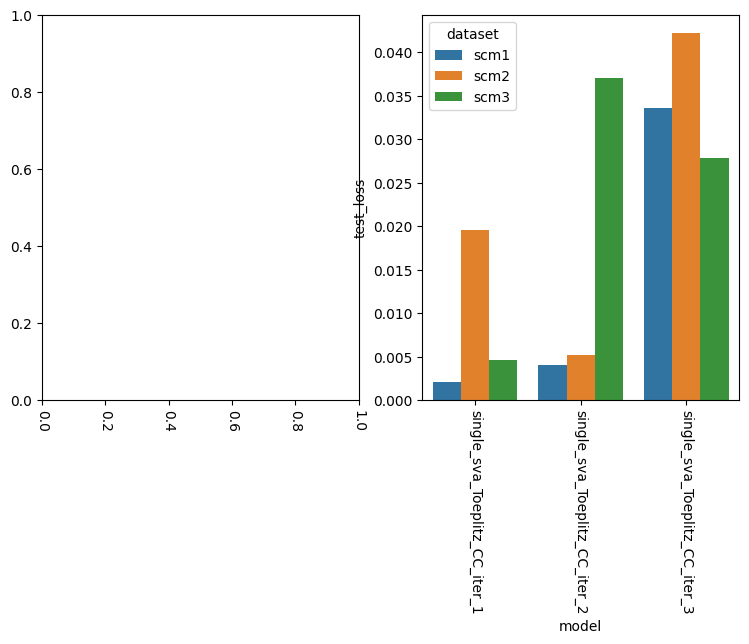

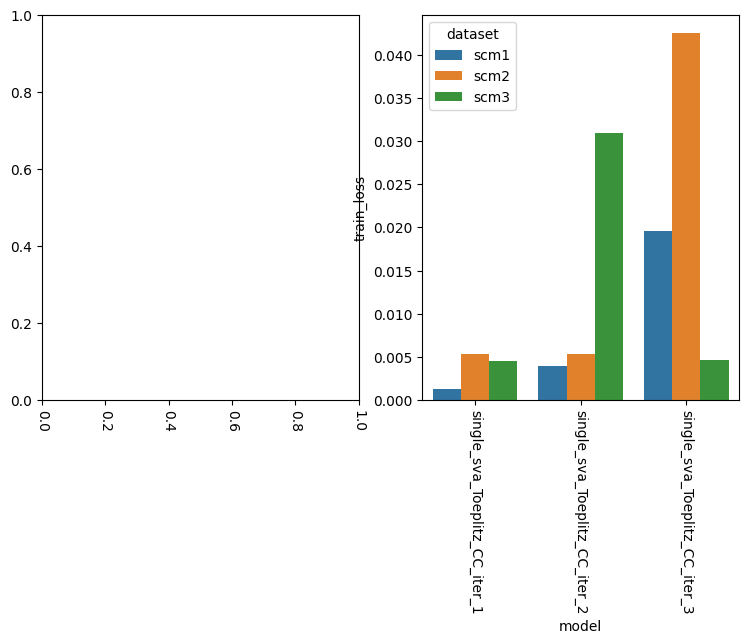

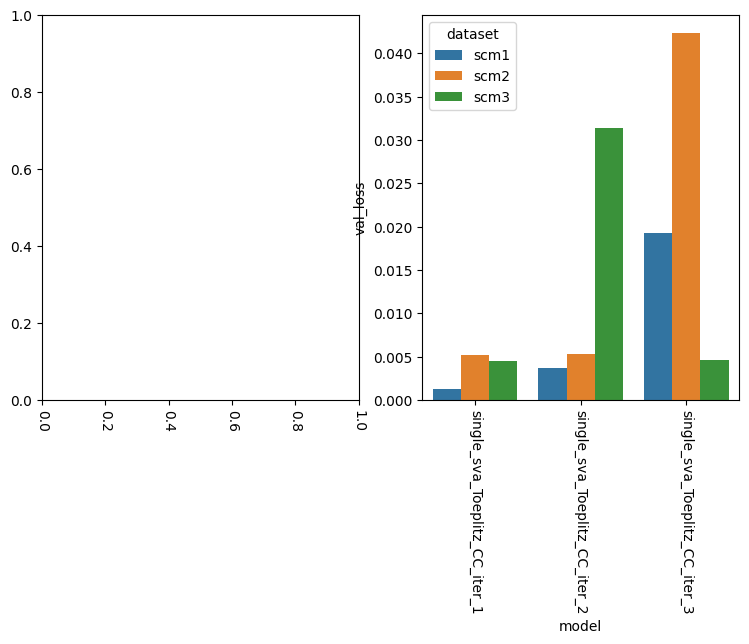

In [30]:

fig, axs = plt.subplots(1,2, figsize = (9,5))
sns.barplot(dfme_summary[dfme_summary["model"].str.contains("na_")], x="model", y="test_loss", hue="dataset", ax=axs[0])
sns.barplot(dfme_summary[dfme_summary["model"].str.contains("single_")], x="model", y="test_loss", hue="dataset", ax=axs[1])
for i in range(len(axs)):
        axs[i].tick_params(axis='x', labelrotation=-90)
        
fig, axs = plt.subplots(1,2, figsize = (9,5))
sns.barplot(dfme_summary[dfme_summary["model"].str.contains("na_")], x="model", y="train_loss", hue="dataset", ax=axs[0])
sns.barplot(dfme_summary[dfme_summary["model"].str.contains("single_")], x="model", y="train_loss", hue="dataset", ax=axs[1])
for i in range(len(axs)):
        axs[i].tick_params(axis='x', labelrotation=-90)
        
        
fig, axs = plt.subplots(1,2, figsize = (9,5))
sns.barplot(dfme_summary[dfme_summary["model"].str.contains("na_")], x="model", y="val_loss", hue="dataset", ax=axs[0])
sns.barplot(dfme_summary[dfme_summary["model"].str.contains("single_")], x="model", y="val_loss", hue="dataset", ax=axs[1])
for i in range(len(axs)):
        axs[i].tick_params(axis='x', labelrotation=-90)


In [31]:
def eval_model(model_label, error_label = "abs_error_mean", baseline_label="baseline", dfbase=df, dfm=dfm):
    dfbase_ = dfbase.set_index(["model", "hard", "dataset", "intervention", "variable", "dist_group", "struct_group", "path_type"])
    dfm_ = dfm.set_index(["model", "hard", "dataset", "intervention", "variable", "dist_group", "struct_group", "path_type"])
    dfna_diff = (dfbase_.loc[baseline_label][error_label] - dfm_.loc[model_label][error_label])/(dfbase_.loc[baseline_label][error_label])*100 # positive = good!
    
    fig1 = plt.figure()
    sns.scatterplot(dfna_diff.reset_index().dropna(), x="variable", y=error_label, hue="path_type", style="dataset", s=100)
    plt.grid(True)
    plt.title(model_label)
    
    fig2 = plt.figure()
    sns.barplot(dfna_diff.reset_index(), x="dataset", y=error_label, hue="path_type")
    plt.grid(True)
    plt.title(model_label)
    
    plt.show([fig1,fig2])

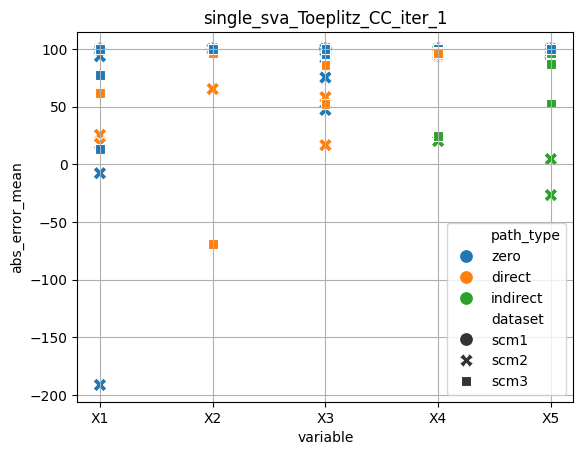

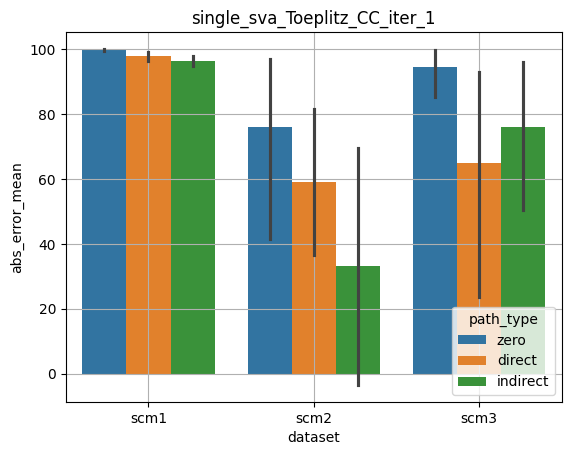

In [32]:
eval_model("single_sva_Toeplitz_CC_iter_1")

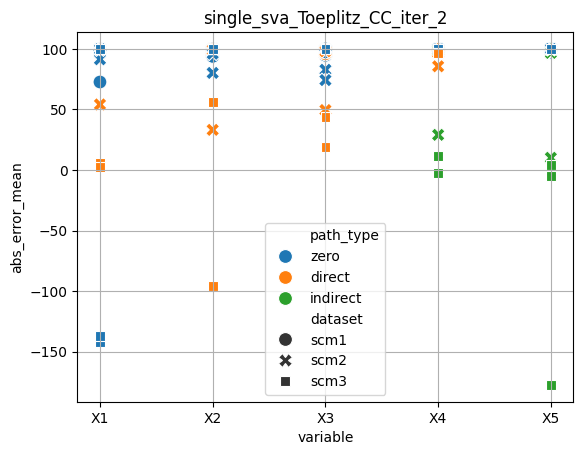

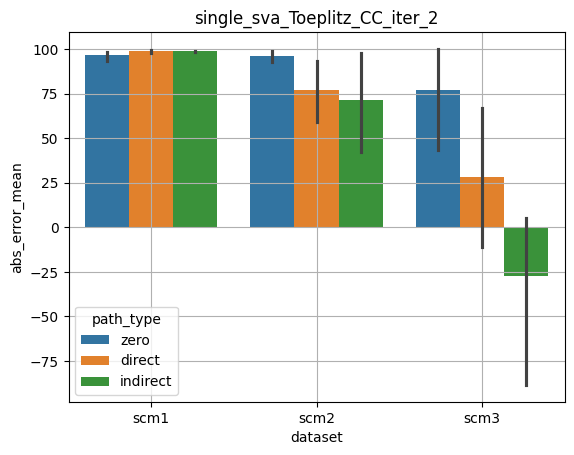

In [33]:
eval_model("single_sva_Toeplitz_CC_iter_2")


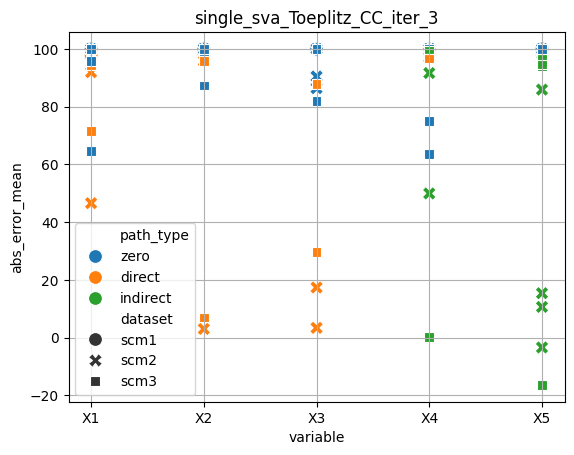

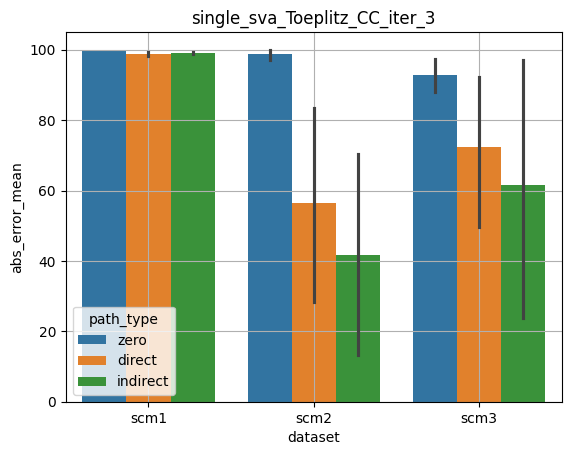

In [34]:
eval_model("single_sva_Toeplitz_CC_iter_3")

## Seed Runs

In [35]:
ate_summary_filename = "ate_summary.csv"
experiment_summary_filename = "experiment_summary.csv"
intermediate_path = "eval/eval_seed_sweep/files"

baseline_list = [
    {
        "model"     : "single_Toeplitz_Sigmoid_svfa",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_9/results/single_Toeplitz_Sigmoid_svfa_scm1c_65003413"
        },
    {
        "model"     : "single_Toeplitz_Sigmoid_svfa",
        "dataset"   : "scm2",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_9/results/single_Toeplitz_Sigmoid_svfa_scm2c_65002969"
        },
    {
        "model"     : "single_Toeplitz_Sigmoid_svfa",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_9/results/single_Toeplitz_Sigmoid_svfa_scm3c_64998795"
        },
    
    {
        "model"     : "single_Toeplitz_CC_svfa",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_9 - Copy/results/single_Toeplitz_CausalCross_svfa_scm1c_65030838"
        },
    
    {
        "model"     : "single_Toeplitz_CC_svfa",
        "dataset"   : "scm2",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_9 - Copy/results/single_Toeplitz_CausalCross_svfa_scm2c_65030900"
        },
    {
        "model"     : "single_Toeplitz_CC_svfa",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_9 - Copy/results/single_Toeplitz_CausalCross_svfa_scm3c_65029832"
        },
    
    # iter_11
    {
        "model"     : "single_Toeplitz_CC_svfa_CV",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_11/results/single_Toeplitz_CC_svfa_scm1c_65051296"
        },
    {
        "model"     : "single_Toeplitz_CC_svfa_CV",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_11/results/single_Toeplitz_CC_svfa_scm3c_65051940"
        },

]

dfms = None
dfmse = None

for d in baseline_list:    
    # ATE dfms
    dfms_ = pd.read_csv(join(d["filepath"], intermediate_path, ate_summary_filename))
    dfms_["model"] = d["model"]
    dfms_["dataset"] = d["dataset"]
    dfms_["hard"] = d["hard"]
    
    if dfms is None:
        dfms = dfms_
    else:
        dfms = pd.concat([dfms, dfms_], axis=0)
    
    # exp dfms
    dfe_ = pd.read_csv(join(d["filepath"], intermediate_path, experiment_summary_filename))
    dfe_["model"] = d["model"]
    dfe_["dataset"] = d["dataset"]
    dfe_["hard"] = d["hard"]
    
    if dfmse is None:
        dfmse = dfe_
    else:
        dfmse = pd.concat([dfmse, dfe_], axis=0)
        
            
dfms = add_ate_groups(dfms)
dfms["intervention_on_variable"]=dfms["intervention"]+"_"+dfms["variable"]

dfms_ = dfms.set_index(["model", "hard", "dataset", "intervention", "variable", "dist_group", "struct_group", "path_type"])

agg_df = aggregate_ate_by_groups(dfms)

display(agg_df.pivot_table(
    index=["model", "dataset", "hard"],
    columns="group_label",
    values=["abs_error", "abs_error_std"]
))

abs_error                        \
group_label                                ID_nonzero   ID_zero OOD_nonzero   
model                        dataset hard                                     
single_Toeplitz_CC_svfa      scm1    False   0.056852  0.004036    0.188449   
                             scm2    False   0.176822  0.006013    0.920591   
                             scm3    False   0.238878  0.009586    0.845626   
single_Toeplitz_CC_svfa_CV   scm1    False   0.162085  0.012394    0.495647   
                             scm3    False   0.433358  0.018449    1.154878   
single_Toeplitz_Sigmoid_svfa scm1    False   0.007093  0.004667    0.023647   
                             scm2    False   0.208603  0.011232    0.888288   
                             scm3    False   0.233322  0.011062    0.820511   

                                                     abs_error_std            \
group_label                                 OOD_zero    ID_nonzero   ID_zero   
model                        dataset hard                                      
single_Toeplitz_CC_svfa      scm1    False  0.013850      0.052677  0.002772   
                             scm2    False  0.041369      0.077622  0.003953   
                             scm3    False  0.067968      0.061608  0.006228   
single_Toeplitz_CC_svfa_CV   scm1    False  0.058746      0.029136  0.004109   
                             scm3    False  0.066698      0.069764  0.015135   
single_Toeplitz_Sigmoid_svfa scm1    False  0.018659      0.001851  0.001187   
                             scm2    False  0.049175      0.060924  0.006018   
                             scm3    False  0.060343      0.013819  0.003080   

                                                                  
group_label                                OOD_nonzero  OOD_zero  
model                        dataset hard                         
single_Toeplitz_CC_svfa      scm1    False    0.155988  0.010659  
                             scm2    False    0.185334  0.031916  
                             scm3    False    0.174483  0.060188  
single_Toeplitz_CC_svfa_CV   scm1    False    0.084143  0.017997  
                             scm3    False    0.213627  0.050482  
single_Toeplitz_Sigmoid_svfa scm1    False    0.007285  0.004643  
                             scm2    False    0.164909  0.025896  
                             scm3    False    0.123471  0.038500

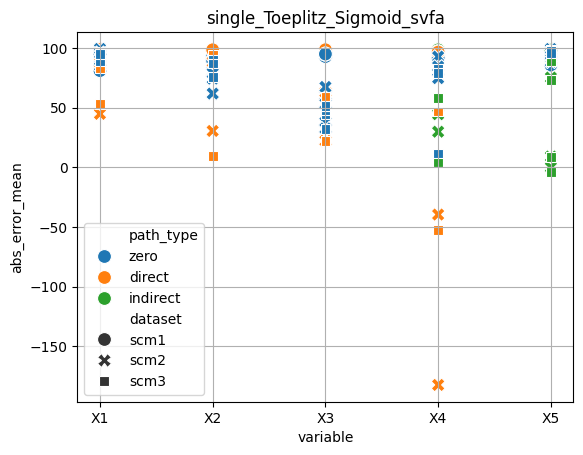

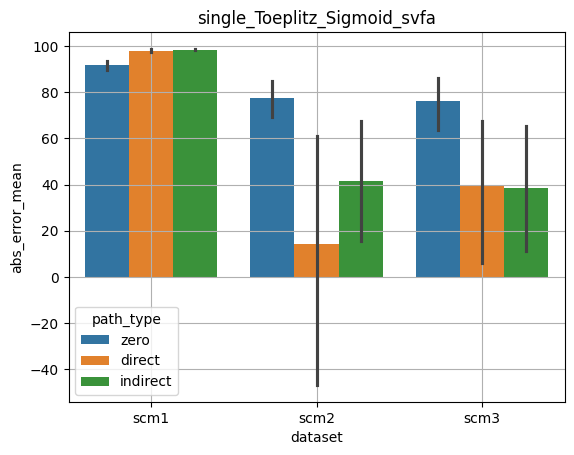

In [36]:
eval_model(model_label="single_Toeplitz_Sigmoid_svfa", error_label = "abs_error_mean", baseline_label="baseline", dfbase=df, dfm=dfms)

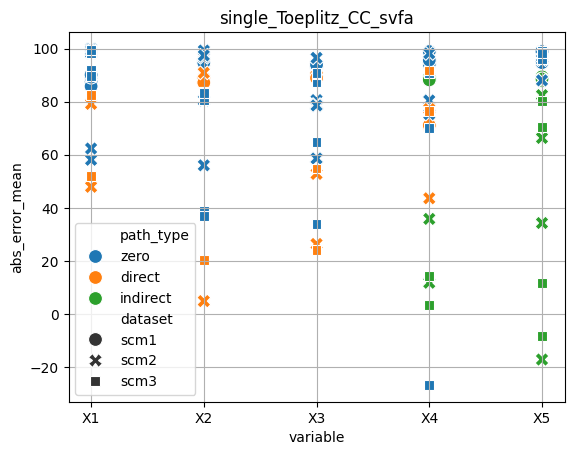

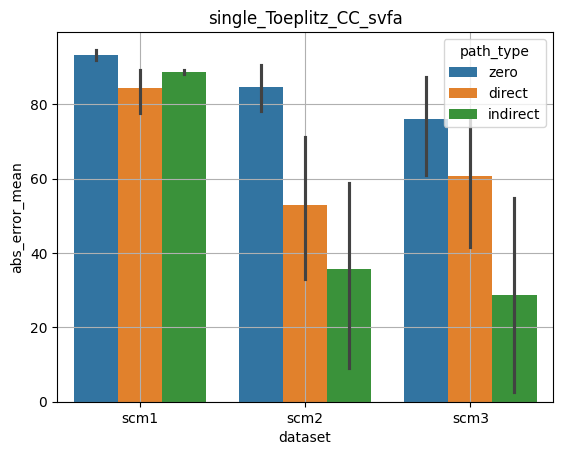

In [37]:
eval_model(model_label="single_Toeplitz_CC_svfa", error_label = "abs_error_mean", baseline_label="baseline", dfbase=df, dfm=dfms)

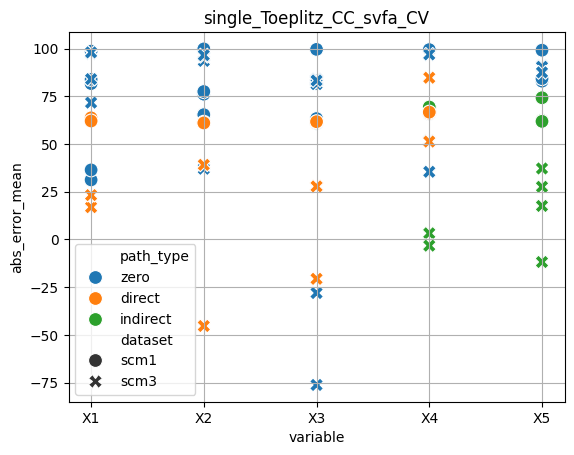

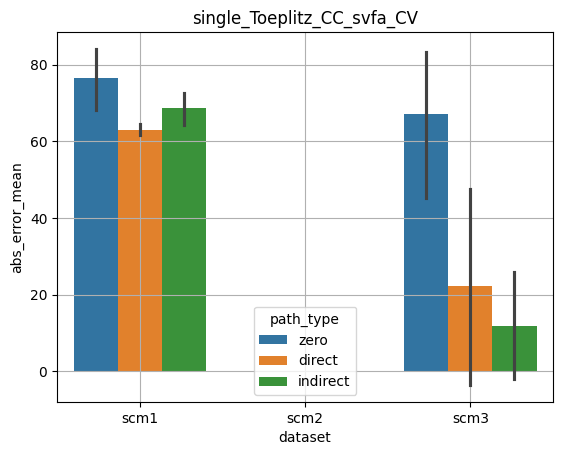

In [38]:
eval_model(model_label="single_Toeplitz_CC_svfa_CV", error_label = "abs_error_mean", baseline_label="baseline", dfbase=df, dfm=dfms)

## Aggregated DAG Heatmap

Visualises the per-edge inferred probabilities aggregated across seeds (from `aggregate_dag.json` produced by `eval_seed_sweep`).
Each cell shows the seed-mean (and the ±std underneath). Toggle `show_ground_truth=True` to switch the same axes to the binary true mask — no additional axes are added.

In [39]:
def plot_aggregate_dag(
    sweep_path: str,
    show_ground_truth: bool = False,
    blocks: list | None = None,
    cmap: str = "viridis",
    annot_fontsize: int = 9,
    figsize_per_block: tuple = (4.2, 4.0),
    title_prefix: str = "",
):
    """Plot the aggregated learned DAG (mean ± std across seeds) as one heatmap
    per attention block, side-by-side on a single row.

    The `show_ground_truth` flag toggles the SAME axes between:
      - False (default): color = seed-mean, annotation = `mean` (and `±std` below)
      - True           : color = true binary mask, annotation = `0`/`1`
    No extra axes are added when toggling.

    Args:
        sweep_path: path to a sweep experiment folder (the one passed to
            ``eval_seed_sweep``). Reads
            ``<sweep_path>/eval/eval_seed_sweep/files/aggregate_dag.json``.
        show_ground_truth: see above.
        blocks: list of block names to plot (e.g. ``['dec_cross', 'dec_self']``).
            Defaults to all blocks present in the JSON.
        cmap, annot_fontsize, figsize_per_block, title_prefix: cosmetic.

    Returns:
        (fig, axes) for further customisation / saving.
    """
    json_path = join(sweep_path, "eval", "eval_seed_sweep", "files", "aggregate_dag.json")
    with open(json_path) as f:
        payload = json.load(f)

    all_blocks = list(payload.get("blocks", {}).keys())
    if not all_blocks:
        raise ValueError(f"No blocks found in {json_path}")
    block_names = list(blocks) if blocks else all_blocks
    missing = [b for b in block_names if b not in payload["blocks"]]
    if missing:
        raise KeyError(f"Block(s) {missing} not in aggregate_dag.json (available: {all_blocks})")

    n_seeds = payload.get("n_seeds", "?")
    datasets = payload.get("datasets", [])
    archs = payload.get("architectures", [])

    n_blocks = len(block_names)
    fig, axes = plt.subplots(
        1, n_blocks,
        figsize=(figsize_per_block[0] * n_blocks, figsize_per_block[1]),
        squeeze=False,
    )
    axes = axes[0]

    for ax, block_name in zip(axes, block_names):
        b = payload["blocks"][block_name]
        mean = np.asarray(b["mean"], dtype=float)
        std  = np.asarray(b.get("std", np.zeros_like(mean)), dtype=float)
        true = np.asarray(b.get("true", []), dtype=float) if b.get("true") else None
        row_labels = b.get("row_labels", [str(i) for i in range(mean.shape[0])])
        col_labels = b.get("col_labels", [str(j) for j in range(mean.shape[1])])

        if show_ground_truth:
            if true is None or true.size == 0:
                raise ValueError(f"Block '{block_name}' has no 'true' mask in {json_path}")
            data = true
            vmin, vmax = 0.0, 1.0
            title = f"{block_name} (ground truth)"
        else:
            data = mean
            vmin, vmax = 0.0, 1.0
            title = f"{block_name} (mean ±std, seeds={n_seeds})"
        if title_prefix:
            title = f"{title_prefix} — {title}"

        im = ax.imshow(data, vmin=vmin, vmax=vmax, cmap=cmap, aspect="auto")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        n_rows, n_cols = data.shape
        for i in range(n_rows):
            for j in range(n_cols):
                cell_val = data[i, j]
                # contrasting text colour
                color = "white" if cell_val < 0.55 else "black"
                if show_ground_truth:
                    ax.text(j, i, f"{int(round(cell_val))}",
                            ha="center", va="center",
                            color=color, fontsize=annot_fontsize + 1, fontweight="bold")
                else:
                    s = std[i, j] if std.shape == data.shape else 0.0
                    if s > 0:
                        ax.text(j, i - 0.12, f"{cell_val:.2f}",
                                ha="center", va="center",
                                color=color, fontsize=annot_fontsize, fontweight="bold")
                        ax.text(j, i + 0.20, f"±{s:.2f}",
                                ha="center", va="center",
                                color=color, fontsize=max(annot_fontsize - 2, 6))
                    else:
                        ax.text(j, i, f"{cell_val:.2f}",
                                ha="center", va="center",
                                color=color, fontsize=annot_fontsize, fontweight="bold")

        ax.set_xticks(range(n_cols))
        ax.set_xticklabels(col_labels, rotation=0)
        ax.set_yticks(range(n_rows))
        ax.set_yticklabels(row_labels)
        # Cross block: cols are sources (S), rows are targets (X)
        if "cross" in (b.get("mask_type") or block_name):
            ax.set_xlabel("Sources (S)")
            ax.set_ylabel("Targets (X)")
        else:
            ax.set_xlabel("Sources (X)")
            ax.set_ylabel("Targets (X)")
        ax.set_title(title, fontsize=10)

    suptitle_bits = []
    if datasets:
        suptitle_bits.append("dataset=" + ",".join(datasets))
    if archs:
        suptitle_bits.append("arch=" + ",".join(archs))
    if suptitle_bits:
        fig.suptitle(" | ".join(suptitle_bits), fontsize=11)
    plt.tight_layout()
    return fig, axes

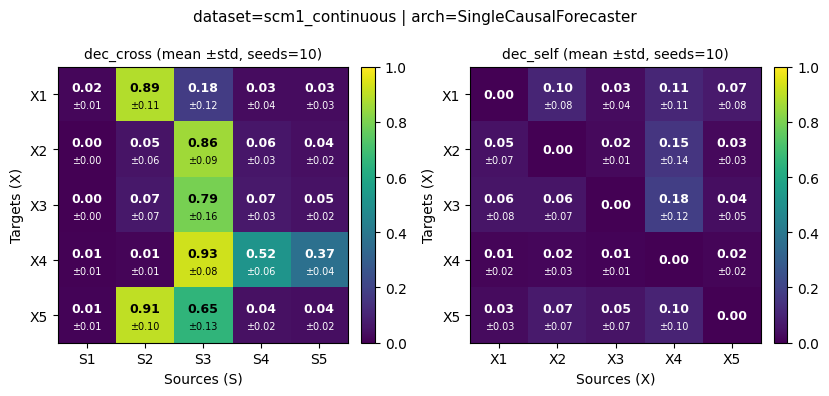

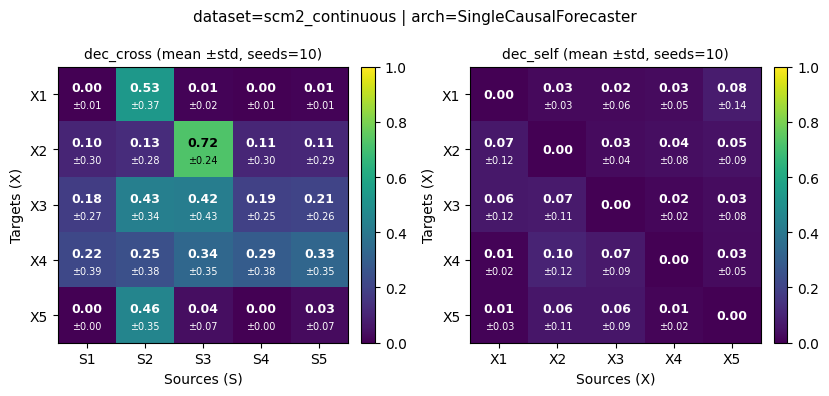

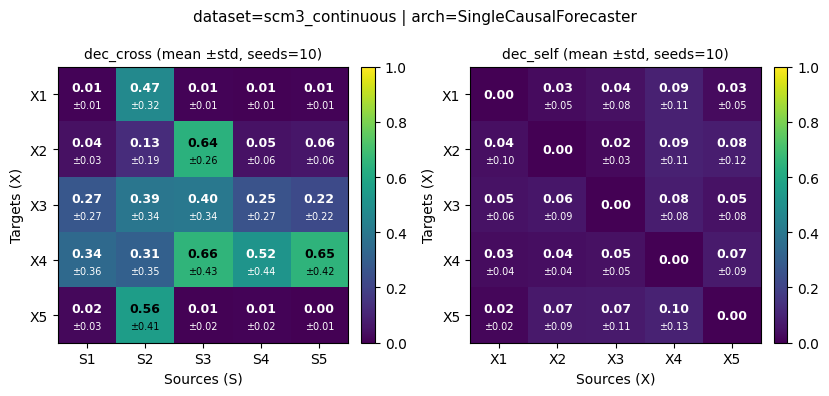

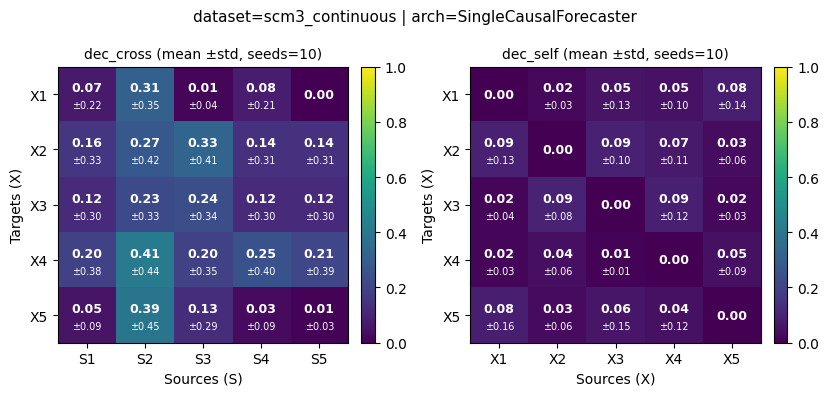

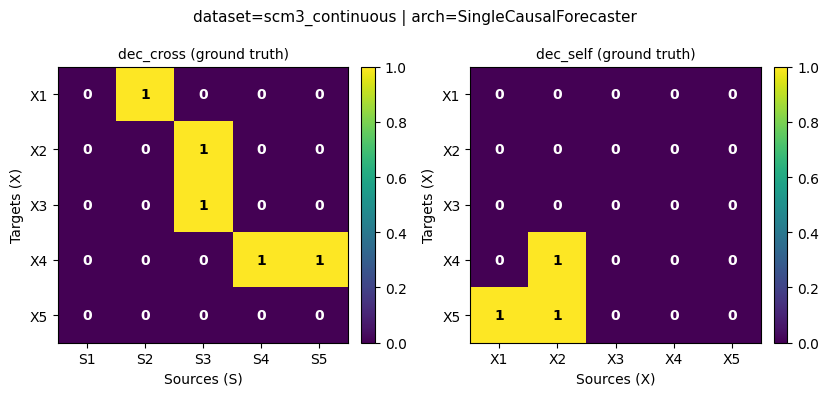

In [40]:
sweep_path = "../experiments/single/calitrain/iter_9/results/single_Toeplitz_Sigmoid_svfa_scm3c_64998795"

# 1) Aggregate learned DAG (mean ±std across seeds)
fig, _ = plot_aggregate_dag(sweep_path="../experiments/single/calitrain/iter_9/results/single_Toeplitz_Sigmoid_svfa_scm1c_65003413", show_ground_truth=False)
plt.show()

fig, _ = plot_aggregate_dag(sweep_path="../experiments/single/calitrain/iter_9/results/single_Toeplitz_Sigmoid_svfa_scm2c_65002969", show_ground_truth=False)
plt.show()

fig, _ = plot_aggregate_dag(sweep_path="../experiments/single/calitrain/iter_9/results/single_Toeplitz_Sigmoid_svfa_scm3c_64998795", show_ground_truth=False)
plt.show()

fig, _ = plot_aggregate_dag(sweep_path="../experiments/single/calitrain/iter_9 - Copy/results/single_Toeplitz_CausalCross_svfa_scm3c_65029832", show_ground_truth=False)
plt.show()

# 2) Same axes layout, switched to the ground-truth mask
fig, _ = plot_aggregate_dag(sweep_path="../experiments/single/calitrain/iter_9/results/single_Toeplitz_Sigmoid_svfa_scm3c_64998795", show_ground_truth=True)
plt.show()

---

# SHD vs HSIC from Causal Initialization

Scatter plot of Soft Hamming Distance (SHD) vs HSIC after causal initialization, per seed. Each point is one seed candidate. If HSIC is a good proxy for structure recovery, we expect a positive correlation: lower HSIC → lower SHD.

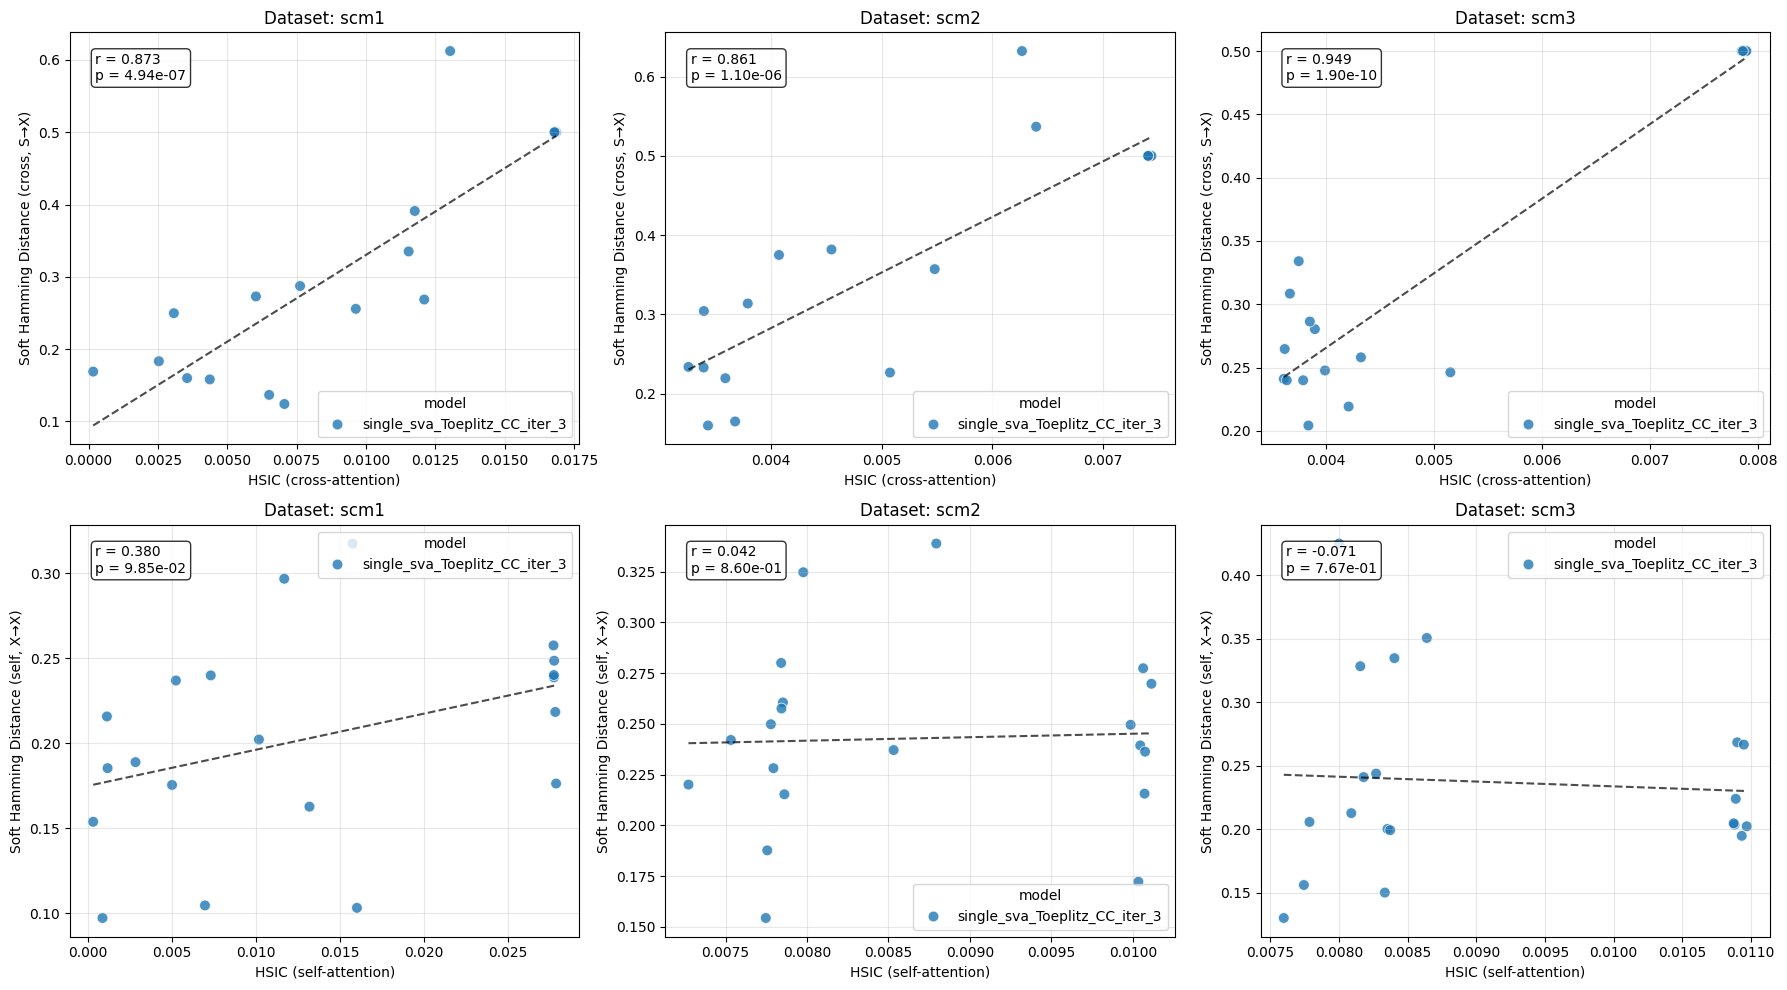

In [41]:
assert not df_ci.empty, "df_ci is empty — no causal_init_summary.json files were found."

# Drop rows where SHD cross is missing
df_plot = df_ci.dropna(subset=["hsic_cross", "shd_cross"]).copy()

model = "single_sva_Toeplitz_CC_iter_3"
df_plot = df_plot[df_plot["model"] == model]

datasets = sorted(df_plot["dataset"].unique())
n_ds = len(datasets)

# Row 0: SHD cross vs HSIC cross (S→X)
# Row 1: SHD self  vs HSIC self  (X→X) — falls back to HSIC cross if hsic_self unavailable
shd_configs = [
    ("shd_cross", "hsic_cross", "Soft Hamming Distance (cross, S→X)", "HSIC (cross-attention)"),
    ("shd_self",  "hsic_self",  "Soft Hamming Distance (self, X→X)",  "HSIC (self-attention)"),
]

fig, axes = plt.subplots(len(shd_configs), n_ds, figsize=(6 * n_ds, 5 * len(shd_configs)), squeeze=False)

for row, (shd_col, hsic_col, ylabel, xlabel) in enumerate(shd_configs):
    for col, ds in enumerate(datasets):
        ax = axes[row, col]
        sub = df_plot[df_plot["dataset"] == ds].dropna(subset=[shd_col])
        
        # Choose x-axis: use hsic_self when available, fall back to hsic_cross
        has_hsic_col = hsic_col in sub.columns and sub[hsic_col].notna().any()
        x_col = hsic_col if has_hsic_col else "hsic_cross"
        actual_xlabel = xlabel if has_hsic_col else f"{xlabel} [using hsic_cross — hsic_self not logged]"
        sub = sub.dropna(subset=[x_col])
        
        # Scatter
        sns.scatterplot(
            data=sub, x=x_col, y=shd_col,
            hue="model", style="model", s=60, alpha=0.8, ax=ax,
        )
        
        # Linear fit + Pearson r
        x = sub[x_col].values
        y = sub[shd_col].values
        if len(x) >= 3:
            r, p = stats.pearsonr(x, y)
            slope, intercept = np.polyfit(x, y, 1)
            x_fit = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_fit, slope * x_fit + intercept, "k--", lw=1.5, alpha=0.7)
            ax.text(
                0.05, 0.95, f"r = {r:.3f}\np = {p:.2e}",
                transform=ax.transAxes, va="top", fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
            )
        
        ax.set_xlabel(actual_xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f"Dataset: {ds}")
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Summary Table: Abs. ATE Error by (dataset, path_type, intervention magnitude)

Aggregates per-pair `(abs_error_mean, abs_error_std)` (already averaged over seeds) into one cell per `(dataset, path_type, |intervention|)` group using the **law of total variance**:

$$\mu_g = \tfrac{1}{N}\sum_i \mu_i, \quad \sigma_g^2 = \tfrac{1}{N}\sum_i \sigma_i^2 + \tfrac{1}{N-1}\sum_i (\mu_i - \mu_g)^2$$

Splitting by intervention magnitude (`|s|`) keeps pairs of similar effect-size scale together so the between-pair term shrinks. The magnitude is annotated `(ID)`/`(OOD)` based on `dist_group`.

$\Delta\%$ vs Baseline = $100 \cdot (\mu_{\text{base}} - \mu_{\text{method}})/\mu_{\text{base}}$ — **positive = method better than baseline**.

In [42]:
def add_intervention_magnitude(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add `intv_value` (signed float, e.g. -1.5) and `intv_mag` (= |intv_value|, e.g. 1.5)
    columns to a dataframe whose `intervention` column is formatted as 'S2=0.5'.
    Idempotent.
    """
    df = df.copy()
    if "intv_value" not in df.columns:
        df["intv_value"] = df["intervention"].astype(str).str.extract(r"=(-?[\d.]+)")[0].astype(float)
    if "intv_mag" not in df.columns:
        df["intv_mag"] = df["intv_value"].abs()
    return df


def aggregate_abs_error(
    df: pd.DataFrame,
    group_cols=("dataset", "path_type", "intv_mag"),
    mean_col: str = "abs_error_mean",
    std_col: str = "abs_error_std",
) -> pd.DataFrame:
    """
    Aggregate per-pair (mean, std) into per-group (mean, std) using the law of total variance.

    For each group with N pairs (mu_i, sigma_i):
        mu_g     = mean_i mu_i
        var_g    = mean_i sigma_i^2  +  Var_i(mu_i)        (within + between)
        sigma_g  = sqrt(var_g)

    Returns DataFrame with columns: *group_cols, n_pairs, mean, std.
    """
    rows = []
    for keys, sub in df.groupby(list(group_cols)):
        mu = sub[mean_col].astype(float).values
        sd = sub[std_col].fillna(0.0).astype(float).values
        n = len(mu)
        if n == 0:
            continue
        mu_g = float(np.mean(mu))
        within = float(np.mean(sd ** 2))
        between = float(np.var(mu, ddof=1)) if n > 1 else 0.0
        sigma_g = float(np.sqrt(within + between))
        row = dict(zip(group_cols, keys if isinstance(keys, tuple) else (keys,)))
        row.update({"n_pairs": n, "mean": mu_g, "std": sigma_g})
        rows.append(row)
    return pd.DataFrame(rows)


def compute_delta_pct(
    base: pd.DataFrame,
    method: pd.DataFrame,
    group_cols=("dataset", "path_type"),
) -> pd.DataFrame:
    """
    Compute Delta% = 100 * (mu_base - mu_method) / mu_base with first-order error propagation:
        sigma_Delta = (100 / |mu_base|) * sqrt(sigma_base^2 + sigma_method^2)
    Positive Delta% means the method has lower error than the baseline.
    """
    m = base.merge(method, on=list(group_cols), suffixes=("_base", "_meth"))
    denom = m["mean_base"].abs().replace(0.0, np.nan)
    m["delta_pct"] = 100.0 * (m["mean_base"] - m["mean_meth"]) / denom
    m["delta_pct_std"] = 100.0 * np.sqrt(m["std_base"] ** 2 + m["std_meth"] ** 2) / denom
    return m[list(group_cols) + ["delta_pct", "delta_pct_std"]]


def _fmt_pm(mean: float, std: float, decimals: int = 2) -> str:
    if pd.isna(mean):
        return "--"
    if pd.isna(std):
        return f"{mean:.{decimals}f}"
    return f"{mean:.{decimals}f} ± {std:.{decimals}f}"


def _fmt_pm_latex(mean: float, std: float, decimals: int = 2, bold: bool = False) -> str:
    if pd.isna(mean):
        return "--"
    s = f"{mean:.{decimals}f}" if pd.isna(std) else f"{mean:.{decimals}f} \\pm {std:.{decimals}f}"
    s = f"${s}$"
    return f"\\textbf{{{s}}}" if bold else s


def _fmt_delta(mean: float, std: float, decimals: int = 1, bold: bool = False, latex: bool = False) -> str:
    if pd.isna(mean):
        return "--"
    sign = "+" if mean >= 0 else ""
    body = f"{sign}{mean:.{decimals}f} ± {std:.{decimals}f}" if not pd.isna(std) else f"{sign}{mean:.{decimals}f}"
    if latex:
        body = f"${body.replace('±', '\\pm')}$"
        return f"\\textbf{{{body}}}" if bold else body
    return f"**{body}**" if bold else body


def _build_mag_label(value: float, dist_group: str, mag_decimals: int = 1) -> str:
    if pd.isna(value):
        return "--"
    return f"{value:.{mag_decimals}f} ({dist_group})"


def build_summary_table(
    df_baseline: pd.DataFrame,
    df_model: pd.DataFrame | None = None,
    df_oracle: pd.DataFrame | None = None,
    group_cols=("dataset", "path_type", "intv_mag"),
    path_type_order=("direct", "indirect", "zero"),
    dataset_order=None,
    decimals: int = 2,
    mag_decimals: int = 1,
    method_label: str = "Ours",
    oracle_label: str = "Oracle",
) -> tuple[pd.DataFrame, pd.DataFrame, str]:
    """
    Build the main summary table comparing Baseline vs (optional) Oracle vs (optional) Ours,
    aggregated by `group_cols` (default: dataset × path_type × |intervention|).

    Each row label uses the magnitude annotated with its distribution group, e.g. '0.5 (ID)',
    looked up from the baseline dataframe (mode of `dist_group` within the cell).

    Returns:
        raw_df    : numeric DataFrame with means/stds and deltas (one row per group).
        display_df: human-readable DataFrame with formatted 'mean ± std' cells.
        latex_str : booktabs LaTeX string.
    """
    group_cols = list(group_cols)
    use_mag = "intv_mag" in group_cols

    # Make sure intv_mag/intv_value exist on every input that needs them
    if use_mag:
        df_baseline = add_intervention_magnitude(df_baseline)
        if df_model is not None:
            df_model = add_intervention_magnitude(df_model)
        if df_oracle is not None:
            df_oracle = add_intervention_magnitude(df_oracle)

    base_agg = aggregate_abs_error(df_baseline, group_cols=group_cols)
    parts = {"Baseline": base_agg}
    deltas = {}
    if df_oracle is not None:
        oracle_agg = aggregate_abs_error(df_oracle, group_cols=group_cols)
        parts[oracle_label] = oracle_agg
        deltas[oracle_label] = compute_delta_pct(base_agg, oracle_agg, group_cols=group_cols)
    if df_model is not None:
        model_agg = aggregate_abs_error(df_model, group_cols=group_cols)
        parts[method_label] = model_agg
        deltas[method_label] = compute_delta_pct(base_agg, model_agg, group_cols=group_cols)

    # Merge means/stds onto a single wide df
    raw = base_agg[group_cols + ["n_pairs"]].copy()
    for name, agg in parts.items():
        raw = raw.merge(
            agg.rename(columns={"mean": f"{name}_mean", "std": f"{name}_std"})[group_cols + [f"{name}_mean", f"{name}_std"]],
            on=group_cols, how="left",
        )
    for name, d in deltas.items():
        raw = raw.merge(
            d.rename(columns={"delta_pct": f"{name}_delta", "delta_pct_std": f"{name}_delta_std"}),
            on=group_cols, how="left",
        )

    # Build mag_label with (ID)/(OOD) tag (mode of dist_group inside each group, from baseline)
    if use_mag:
        if "dist_group" in df_baseline.columns:
            dist_lookup = (
                df_baseline.groupby(group_cols)["dist_group"]
                .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else "--")
                .reset_index()
                .rename(columns={"dist_group": "_dist"})
            )
            raw = raw.merge(dist_lookup, on=group_cols, how="left")
        else:
            raw["_dist"] = ""
        raw["mag_label"] = [
            _build_mag_label(v, d if pd.notna(d) and d != "" else "--", mag_decimals)
            for v, d in zip(raw["intv_mag"], raw["_dist"])
        ]

    # Order rows
    if dataset_order is None:
        dataset_order = sorted(raw["dataset"].unique())
    raw["dataset"] = pd.Categorical(raw["dataset"], categories=dataset_order, ordered=True)
    raw["path_type"] = pd.Categorical(raw["path_type"], categories=path_type_order, ordered=True)
    sort_cols = ["dataset", "path_type"] + (["intv_mag"] if use_mag else [])
    raw = raw.sort_values(sort_cols).reset_index(drop=True)

    # Per-row: which of {Oracle, Ours} has lowest mean (for bolding)
    method_names = [n for n in parts.keys() if n != "Baseline"]
    best_method = None
    if len(method_names) >= 1:
        means = raw[[f"{n}_mean" for n in method_names]]
        best_method = means.idxmin(axis=1).str.replace("_mean", "", regex=False)

    # Build display dataframe
    disp = pd.DataFrame()
    disp["Dataset"] = raw["dataset"].astype(str)
    disp["Path type"] = raw["path_type"].astype(str)
    if use_mag:
        disp["|s|"] = raw["mag_label"].astype(str)
    disp["n"] = raw["n_pairs"].astype(int)
    disp["Baseline"] = [
        _fmt_pm(m, s, decimals) for m, s in zip(raw["Baseline_mean"], raw["Baseline_std"])
    ]
    for name in method_names:
        disp[name] = [
            _fmt_pm(m, s, decimals) for m, s in zip(raw[f"{name}_mean"], raw[f"{name}_std"])
        ]
    for name in method_names:
        disp[f"Δ% {name}"] = [
            _fmt_delta(m, s, decimals=1, bold=False, latex=False)
            for m, s in zip(raw[f"{name}_delta"], raw[f"{name}_delta_std"])
        ]

    # Bold the best method per row in display (markdown-style)
    if best_method is not None and len(method_names) >= 2:
        for i, bm in enumerate(best_method):
            disp.at[i, bm] = f"**{disp.at[i, bm]}**"

    # Build LaTeX table
    n_index_cols = 4 if use_mag else 3   # Dataset | Path type | (|s|) | n
    n_method_cols = 1 + len(method_names)  # Baseline + methods
    n_delta_cols = len(method_names)
    index_spec = "lll r " if use_mag else "ll r "
    col_spec = index_spec + "c" * n_method_cols + (" " + "c" * n_delta_cols if n_delta_cols else "")
    latex_lines = ["\\begin{tabular}{" + col_spec + "}", "\\toprule"]

    # Header row 1: empty index cells + multicolumn group labels
    head1 = [""] * n_index_cols + [f"\\multicolumn{{{n_method_cols}}}{{c}}{{Abs. ATE error $\\downarrow$}}"]
    if n_delta_cols:
        head1.append(f"\\multicolumn{{{n_delta_cols}}}{{c}}{{$\\Delta\\%$ vs Baseline $\\uparrow$}}")
    latex_lines.append(" & ".join(head1) + " \\\\")
    cmid_start = n_index_cols + 1
    cmid_end = n_index_cols + n_method_cols
    cmids = [f"\\cmidrule(lr){{{cmid_start}-{cmid_end}}}"]
    if n_delta_cols:
        cmids.append(f"\\cmidrule(lr){{{cmid_end+1}-{cmid_end+n_delta_cols}}}")
    latex_lines.append(" ".join(cmids))

    # Header row 2: column titles
    head2 = ["Dataset", "Path type"]
    if use_mag:
        head2.append("$|s|$")
    head2 += ["$n$", "Baseline"] + list(method_names) + [f"$\\Delta\\%$ {nm}" for nm in method_names]
    latex_lines.append(" & ".join(head2) + " \\\\")
    latex_lines.append("\\midrule")

    # Body: dedupe Dataset and Path type for readability
    last_dataset = None
    last_path = None
    for i, row in raw.iterrows():
        ds = str(row["dataset"])
        pt = str(row["path_type"])
        if ds != last_dataset and last_dataset is not None:
            latex_lines.append("\\midrule")
        ds_cell = ds if ds != last_dataset else ""
        # Reset path dedup at every dataset change
        if ds != last_dataset:
            last_path = None
        pt_cell = pt if pt != last_path else ""
        last_dataset = ds
        last_path = pt

        bm = best_method.iloc[i] if best_method is not None and len(method_names) >= 2 else None
        cells = [ds_cell, pt_cell]
        if use_mag:
            cells.append(str(row["mag_label"]))
        cells.append(f"{int(row['n_pairs'])}")
        cells.append(_fmt_pm_latex(row["Baseline_mean"], row["Baseline_std"], decimals, bold=False))
        for name in method_names:
            cells.append(_fmt_pm_latex(row[f"{name}_mean"], row[f"{name}_std"], decimals, bold=(name == bm)))
        for name in method_names:
            cells.append(_fmt_delta(row[f"{name}_delta"], row[f"{name}_delta_std"], decimals=1,
                                     bold=(name == bm), latex=True))
        latex_lines.append(" & ".join(cells) + " \\\\")

    latex_lines.append("\\bottomrule")
    latex_lines.append("\\end{tabular}")
    latex_str = "\n".join(latex_lines)

    return raw, disp, latex_str


In [43]:
# Pick the model iteration to report as 'Ours'
selected_model = "single_Toeplitz_CC_svfa"

df_baseline_in = df.copy()
df_model_in = dfms[dfms["model"] == selected_model].copy()
df_oracle_in = None  # plug in the oracle dataframe later when available

raw_df, display_df, latex_str = build_summary_table(
    df_baseline=df_baseline_in,
    df_model=df_model_in,
    df_oracle=df_oracle_in,
    decimals=2,
    method_label="Ours",
    oracle_label="Oracle",
)

print("=== Display DataFrame ===")
display(display_df)

print("\n=== LaTeX (booktabs) ===\n")
print(latex_str)

=== Display DataFrame ===


,Dataset,Path type,|s|,n,Baseline,Ours,Δ% Ours
0,scm1,direct,0.5 (ID),4,0.44 ± 0.14,0.06 ± 0.13,+86.6 ± 43.2
1,scm1,direct,1.5 (OOD),4,1.34 ± 0.41,0.20 ± 0.39,+85.4 ± 42.4
2,scm1,indirect,0.5 (ID),3,0.50 ± 0.17,0.05 ± 0.15,+89.3 ± 45.2
3,scm1,indirect,1.5 (OOD),3,1.51 ± 0.50,0.18 ± 0.44,+88.1 ± 44.6
4,scm1,zero,0.5 (ID),13,0.06 ± 0.04,0.00 ± 0.01,+93.6 ± 61.0
5,scm1,zero,1.5 (OOD),8,0.20 ± 0.12,0.01 ± 0.03,+93.0 ± 60.5
6,scm2,direct,0.5 (ID),4,0.39 ± 0.45,0.06 ± 0.11,+85.2 ± 117.8
7,scm2,direct,1.5 (OOD),4,1.58 ± 1.43,1.02 ± 0.90,+35.6 ± 106.6
8,scm2,indirect,0.5 (ID),3,0.69 ± 0.13,0.33 ± 0.35,+51.8 ± 53.4
9,scm2,indirect,1.5 (OOD),3,1.23 ± 0.78,0.79 ± 0.49,+35.7 ± 75.0



=== LaTeX (booktabs) ===

\begin{tabular}{lll r cc c}
\toprule
 &  &  &  & \multicolumn{2}{c}{Abs. ATE error $\downarrow$} & \multicolumn{1}{c}{$\Delta\%$ vs Baseline $\uparrow$} \\
\cmidrule(lr){5-6} \cmidrule(lr){7-7}
Dataset & Path type & $|s|$ & $n$ & Baseline & Ours & $\Delta\%$ Ours \\
\midrule
scm1 & direct & 0.5 (ID) & 4 & $0.44 \pm 0.14$ & $0.06 \pm 0.13$ & $+86.6 \pm 43.2$ \\
 &  & 1.5 (OOD) & 4 & $1.34 \pm 0.41$ & $0.20 \pm 0.39$ & $+85.4 \pm 42.4$ \\
 & indirect & 0.5 (ID) & 3 & $0.50 \pm 0.17$ & $0.05 \pm 0.15$ & $+89.3 \pm 45.2$ \\
 &  & 1.5 (OOD) & 3 & $1.51 \pm 0.50$ & $0.18 \pm 0.44$ & $+88.1 \pm 44.6$ \\
 & zero & 0.5 (ID) & 13 & $0.06 \pm 0.04$ & $0.00 \pm 0.01$ & $+93.6 \pm 61.0$ \\
 &  & 1.5 (OOD) & 8 & $0.20 \pm 0.12$ & $0.01 \pm 0.03$ & $+93.0 \pm 60.5$ \\
\midrule
scm2 & direct & 0.5 (ID) & 4 & $0.39 \pm 0.45$ & $0.06 \pm 0.11$ & $+85.2 \pm 117.8$ \\
 &  & 1.5 (OOD) & 4 & $1.58 \pm 1.43$ & $1.02 \pm 0.90$ & $+35.6 \pm 106.6$ \\
 & indirect & 0.5 (ID) & 3 & $0.6